In [2]:
pip install statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 2.9 MB/s eta 0:00:04
   ---- ----------------------------------- 1.0/9.5 MB 2.3 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.5 MB 2.0 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.5 MB 2.0 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.5 MB 2.0 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.5 MB 2.0 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.5 MB 1.4 MB/s eta 0:00:06
   -------- ------------------------------- 2.1/9.5 MB 1.4 MB/s eta 0:00:06
   -------- ------------------------------- 2.1/9.5 MB 1.4 MB/s eta 0:00:06
   -------- -------------------------------

# Time series analysis on the data internet airline passengers from 1940 to 1960

In [1]:
# import laibraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from statsmodels.tsa.seasonal import seasonal_decompose 

In [6]:
df = pd.read_csv("resourses/AirPassengers.csv")
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


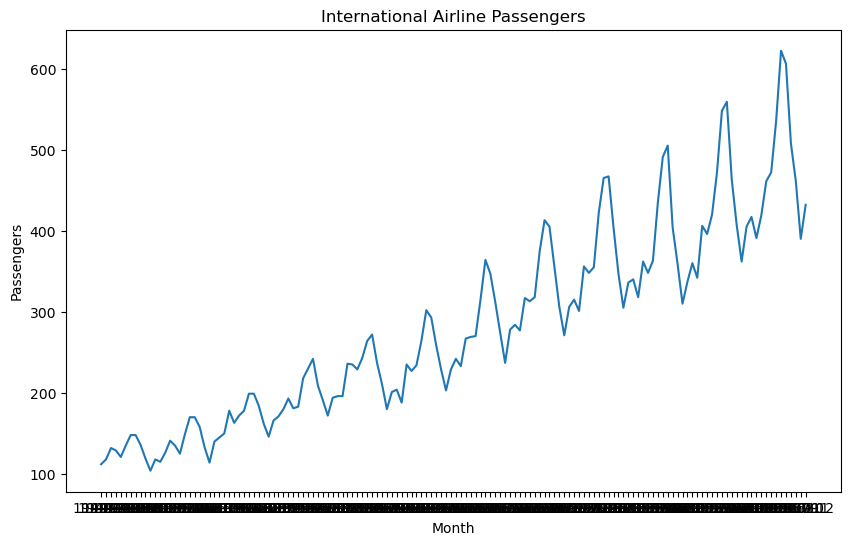

In [7]:
# plot this data to see trends and seasonality

plt.figure(figsize=(10, 6))
plt.plot(df["Month"], df["#Passengers"])
plt.title("International Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.show()


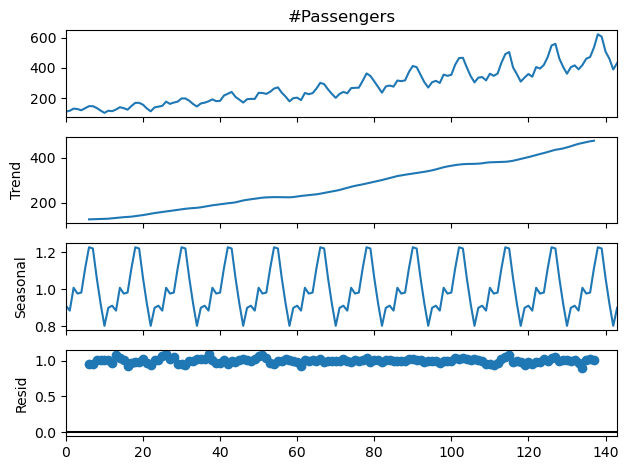

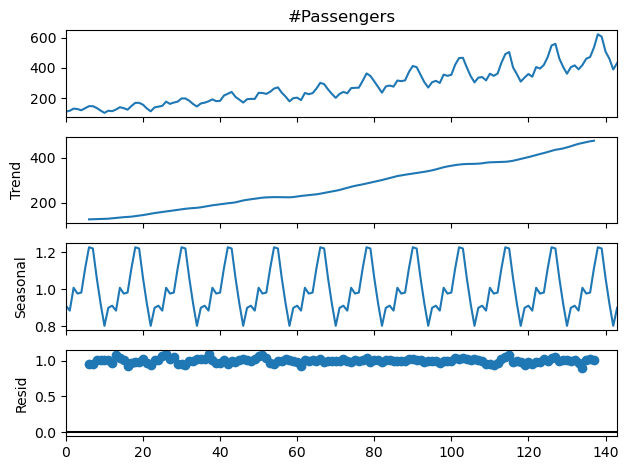

In [8]:
# decompose the data into trands, seasonality and residual
decomposition = seasonal_decompose(df['#Passengers'], model='multiplicative', period=12)
decomposition.plot()


c:\Users\nasik\miniconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 18726.5586 - root_mean_squared_error: 136.8450
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4312.3794 - root_mean_squared_error: 65.6687
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1107.6306 - root_mean_squared_error: 33.2811
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1240.1707 - root_mean_squared_error: 35.2161
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1048.5363 - root_mean_squared_error: 32.3811
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 911.9907 - root_mean_squared_error: 30.1992
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 901.2944 - root_mean_squared_error: 30.0216
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 889.5994 - root_mean_squared_error: 29.8262  
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 876.6432 - root_mean_squared_error: 29.6082
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - 

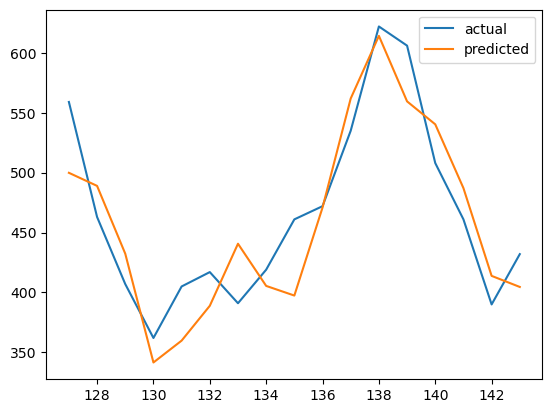

In [9]:
from keras.models import Sequential
from keras.layers import Dense
from keras.metrics import RootMeanSquaredError

# split the data into training and testing sets
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]

# define the number of lagged time steps to use as input features
n_lags = 12

# create the input and output data for the neural network
X_train = np.array([train["#Passengers"].values[i:i+n_lags] for i in range(len(train)-n_lags)])
y_train = np.array(train["#Passengers"].values[n_lags:])
X_test = np.array([test["#Passengers"].values[i:i+n_lags] for i in range(len(test)-n_lags)])
y_test = np.array(test["#Passengers"].values[n_lags:])

# create the neural network model
model = Sequential()
model.add(Dense(10, input_dim=n_lags, activation="relu"))
model.add(Dense(1))
model.compile(loss="mean_squared_error", optimizer="adam", metrics=[RootMeanSquaredError()])

# train the neural network model
model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=1)

# make predictions on the testing set using the trained model
predictions = model.predict(X_test)

# plot the actual and predicted values
plt.plot(test.index[-len(predictions):], test["#Passengers"].values[-len(predictions):], label="actual")
plt.plot(test.index[-len(predictions):], predictions, label="predicted")
plt.legend()
plt.show()